<img src="../pic/CU.png" style="width: 100%; display: block; margin: auto;">

# Курс по прогнозированию временных рядов
# Неделя 5.
# Подбор порядков: четыре стратегии

В ноутбуке `01` мы разобрали, **сколько стоит** обучить одну SARIMA. Но откуда
взялись её порядки $(p,d,q)(P,D,Q)_m$? В большинстве учебных примеров они
появляются из воздуха: «возьмём $(1,1,1)(1,1,1)_{12}$» — и дальше идёт красивый
график.

Сегодня мы закрываем этот пробел. Главная мысль ноутбука:

> **«Подобрать SARIMA» — это не одна кнопка, а спектр стратегий**
> от полностью ручной до полностью автоматической. У каждой свой компромисс
> между **временем**, **качеством** и **контролем**.

## Что мы разберём

| Раздел | Вопрос, на который отвечаем |
|---|---|
| 0 | Что вообще подбираем и **чем** — тестами или критерием? |
| 1 | Стратегия **A**: вручную по ACF/PACF |
| 2 | Стратегия **B**: кандидаты из данных + маленькая сетка |
| 3 | Стратегия **C**: полный перебор по сетке |
| 4 | Стратегия **D**: stepwise (`auto_arima`) |
| 5 | AIC, BIC, AICc — чем они отличаются и когда какой |
| 6 | **Кульминация:** критерий ≠ метрика |

🔍 Чего сегодня **не** будет: сравнения библиотек между собой (это ноутбук `03`)
и разбора того, как считается прогноз (ноутбук `04`). Здесь мы только выбираем
числа $p, d, q, P, D, Q$.

> **Соглашение об оформлении.** Блоки с 🔍 — то, на что стоит обратить внимание
> особо: там прячутся типичные ошибки. **⏱** — ячейки, которые считаются
> заметно дольше секунды; рядом указано ожидаемое время.

In [1]:
import io
import time
import warnings
from contextlib import redirect_stdout
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pmdarima as pm
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf

# Мы намеренно обучаем сотни заведомо неудачных спецификаций — предупреждения
# о несошедшемся оптимизаторе здесь ожидаемы и только мешают читать вывод.
warnings.simplefilter("ignore")

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 110

RANDOM_SEED = 42

/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/5/.venv/lib/python3.11/site-packages/joblib/_multiprocessing_helpers.py:44: UserWarning: [Errno 1] Operation not permitted.  joblib will operate in serial mode
  warnings.warn("%s.  joblib will operate in serial mode" % (e,))


---
# 0. Что вообще подбираем и чем

У SARIMA$(p,d,q)(P,D,Q)_m$ семь чисел, и **подбираются они принципиально
по-разному**. Это разделение почти никогда не проговаривают явно, а из него
следует всё остальное:

| Что | Чем подбираем | Почему именно так |
|---|---|---|
| $m$ | **предметной областью** и спектральным анализом | это свойство данных, а не модели: часовые данные → 24, дневные → 7, месячные → 12 |
| $d$, $D$ | **статистическими тестами** (ADF, KPSS, OCSB, Канова–Хансен) | вопрос «стационарен ли ряд» — это гипотеза, а не вопрос качества подгонки |
| $p$, $q$, $P$, $Q$ | **информационным критерием** (AIC / AICc / BIC) | здесь мы честно сравниваем модели на **одних и тех же** данных |

🔍 Из третьей строки сразу следует ограничение, на котором спотыкаются все:

> **AIC моделей с разным $d$ (или $D$) сравнивать нельзя.**

Правдоподобие — это вероятность **конкретных данных**. Если одна модель
объясняет ряд первых разностей, а другая — ряд вторых разностей, то это
правдоподобия **разных наборов чисел**, и их числовые значения несопоставимы.
Сейчас мы увидим это на числах.

## 0.1. Данные: производство древесины в Канаде

Сквозной ряд этого ноутбука — месячное производство хвойной древесины в Канаде
(данные Statistics Canada). Он удобен тем, что короткий (192 наблюдения),
с очевидной годовой сезонностью $m = 12$ и заметным провалом кризиса 2008–2009
годов.

In [2]:
lumber = (
    pd.read_csv("../data/df_soft.csv", parse_dates=["REF_DATE"], index_col="REF_DATE")["VALUE"]
    .astype(float)
    .asfreq("MS")  # явная месячная частота (начало месяца)
)

# train/test: последние 20% наблюдений откладываем и не трогаем до раздела 6
split = int(len(lumber) * 0.8)
train, test = lumber.iloc[:split], lumber.iloc[split:]

print(f"всего: {len(lumber)},  train: {len(train)},  test: {len(test)}")
print(f"период: {lumber.index.min():%Y-%m} — {lumber.index.max():%Y-%m},  частота: {lumber.index.freq}")

всего: 192,  train: 153,  test: 39
период: 2003-01 — 2018-12,  частота: <MonthBegin>


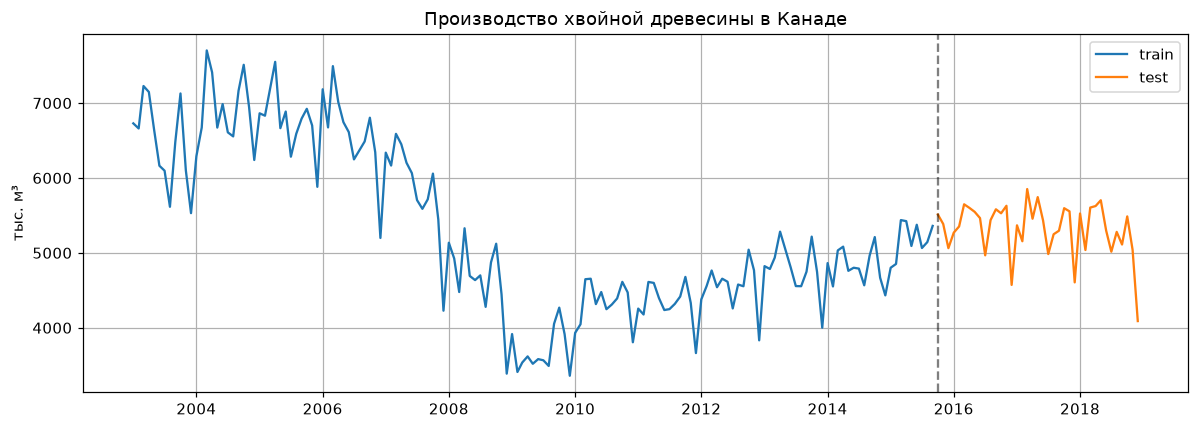

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(train, label="train")
ax.plot(test, label="test", color="C1")
ax.axvline(test.index[0], color="black", ls="--", alpha=0.5)
ax.set(title="Производство хвойной древесины в Канаде", ylabel="тыс. м³")
ax.legend()
fig.tight_layout()

## 0.2. $d$ и $D$ — по тестам

У `pmdarima` для этого есть две готовые функции, и они делают ровно то, что
написано в таблице выше: применяют тест, при необходимости дифференцируют,
применяют снова — и так, пока тест не перестанет отвергать стационарность.

* `ndiffs(y, test=...)` — сколько нужно **обычных** разностей ($d$);
  тесты: `'kpss'` (по умолчанию), `'adf'`, `'pp'`.
* `nsdiffs(y, m, test=...)` — сколько нужно **сезонных** разностей ($D$);
  тесты: `'ocsb'` (по умолчанию), `'ch'` (Канова–Хансен).

In [4]:
for t in ["kpss", "adf", "pp"]:
    print(f"ndiffs(test={t!r:7}) → d = {pm.arima.ndiffs(train, test=t)}")
print()
for t in ["ocsb", "ch"]:
    print(f"nsdiffs(test={t!r:7}, m=12) → D = {pm.arima.nsdiffs(train, m=12, test=t)}")

ndiffs(test='kpss' ) → d = 1
ndiffs(test='adf'  ) → d = 1
ndiffs(test='pp'   ) → d = 1

nsdiffs(test='ocsb' , m=12) → D = 0
nsdiffs(test='ch'   , m=12) → D = 0


🔍 Тесты **не обязаны соглашаться друг с другом**, и это нормально: у них
разные нулевые гипотезы (ADF проверяет «есть единичный корень», KPSS —
«ряд стационарен»). Если $d$ по разным тестам разошлось — это сигнал, что
случай пограничный, и стоит посмотреть на график и попробовать оба варианта.

Обратите внимание и на второй результат: сезонные тесты говорят $D = 0$, хотя
на графике сезонность видна невооружённым глазом. Так тоже бывает: OCSB
проверяет не «есть ли сезонность», а «нужно ли сезонное дифференцирование,
чтобы её убрать». Сезонность **стабильной амплитуды** можно описать сезонными
AR/MA-членами без всякого дифференцирования — а вот «плавающую» сезонность
без $D = 1$ не убрать.

## 0.3. Почему AIC при разном $d$ несравним — на числах

Обучим шесть моделей, отличающихся только порядками дифференцирования, и
посмотрим на две вещи: AIC и **`nobs_effective`** — число наблюдений, реально
попавших в сумму логарифма правдоподобия.

In [5]:
rows = []
for order, sorder in [
    ((1, 0, 1), (0, 0, 0, 0)),
    ((1, 1, 1), (0, 0, 0, 0)),
    ((1, 2, 1), (0, 0, 0, 0)),
    ((1, 1, 1), (1, 0, 1, 12)),
    ((1, 1, 1), (1, 1, 1, 12)),
    ((1, 1, 1), (1, 2, 1, 12)),
]:
    r = SARIMAX(train, order=order, seasonal_order=sorder).fit(disp=False)
    rows.append(
        {
            "спецификация": f"{order}{sorder}",
            "d + D·m": order[1] + sorder[1] * sorder[3],
            "точек в правдоподобии": int(r.nobs_effective),
            "logL": round(r.llf, 1),
            "AIC": round(r.aic, 1),
        }
    )

pd.DataFrame(rows)

,спецификация,d + D·m,точек в правдоподобии,logL,AIC
0,"(1, 0, 1)(0, 0, 0, 0)",0,153,-1150.4,2306.8
1,"(1, 1, 1)(0, 0, 0, 0)",1,152,-1137.5,2281.0
2,"(1, 2, 1)(0, 0, 0, 0)",2,151,-1146.2,2298.4
3,"(1, 1, 1)(1, 0, 1, 12)",1,152,-1068.9,2147.9
4,"(1, 1, 1)(1, 1, 1, 12)",13,140,-977.0,1964.0
5,"(1, 1, 1)(1, 2, 1, 12)",25,128,-923.3,1856.7


🔍 Смотрите на две последние колонки вместе. AIC **монотонно падает** с ростом
$D$: 2148 → 1964 → 1857. Соблазнительно объявить $(1,1,1)(1,2,1)_{12}$
победителем — но посмотрите на «точек в правдоподобии»: 152 → 140 → 128.

Логарифм правдоподобия — это **сумма** вкладов отдельных наблюдений, и каждый
вклад отрицателен. Убрали 24 наблюдения — сумма стала на 24 слагаемых короче,
то есть автоматически больше. Модель не стала лучше: она просто отвечает за
меньший кусок данных.

**Правило, которое надо запомнить:**

> Сначала фиксируем $d$ и $D$ (тестами), и только потом сравниваем по AIC
> модели, у которых $d$ и $D$ одинаковые.

В разделе 3 мы сознательно нарушим это правило — ровно так, как это делают в
реальных ноутбуках, — и посмотрим, к чему это приводит.

---
# 1. Стратегия A — вручную по ACF/PACF

Классическая методология Бокса–Дженкинса. Работает так:

1. привести ряд к стационарности дифференцированием (выбрать $d$, $D$);
2. посмотреть на ACF и PACF **стационарного** ряда;
3. по их форме прочитать порядки $p, q, P, Q$;
4. подогнать 2–4 кандидата и выбрать лучшего.

## 1.1. Данные: ночёвки туристов в Австралии

Здесь берём другой ряд — квартальные данные о числе ночей, проведённых
туристами в Австралии (`austourists`, классический пример из учебника Хайндмана).
Он короткий (68 точек) и очень «чистый»: ручной разбор на нём действительно
работает, а на 5000 точках почасовых данных — уже нет.

In [6]:
raw_tour = pd.read_csv("../data/austourists.csv")

# в файле метки времени записаны как "Q1 1999" — переведём их в кварталы pandas
labels = [f"{y_}{q_}" for q_, y_ in raw_tour["time"].str.strip().str.split()]
parsed = pd.PeriodIndex(labels, freq="Q")
print("дубликатов в разобранном индексе:", parsed.duplicated().sum())

# 🔍 Дубликат есть! В файле одна строка помечена "Q3 2014" вместо "Q2 2014" —
# обычная опечатка в данных. Ряд заведомо непрерывный квартальный, поэтому
# строим индекс явно от первой даты и не доверяем меткам.
tour = pd.Series(
    raw_tour["tourism"].astype(float).to_numpy(),
    index=pd.period_range(parsed[0], periods=len(raw_tour), freq="Q"),
    name="tourism",
)

tour_train, tour_test = tour.iloc[:-8], tour.iloc[-8:]  # тест = последние 2 года
print(f"наблюдений: {len(tour)}, train: {len(tour_train)}, test: {len(tour_test)}")
tour.head()

наблюдений: 68, train: 60, test: 8


1999Q1    30.05251
1999Q2    19.14850
1999Q3    25.31769
1999Q4    27.59144
2000Q1    32.07646
Freq: Q-DEC, Name: tourism, dtype: float64

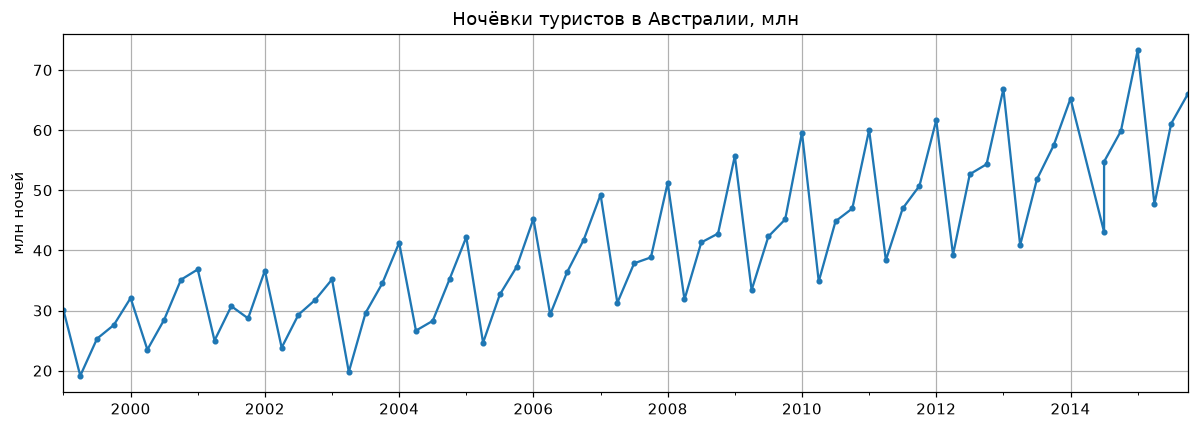

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
tour.plot(ax=ax, marker="o", ms=3)
ax.set(title="Ночёвки туристов в Австралии, млн", ylabel="млн ночей")
fig.tight_layout()

🔍 Полезная привычка: **проверяйте индекс сразу после загрузки.** Дубликат в
датах — это не косметика: `statsmodels` не смог бы определить частоту, прогноз
ушёл бы не на те кварталы, а сравнение прогноза с фактом по индексу молча дало
бы `NaN` вместо ошибки. Опечатка в одной строке из 68 испортила бы весь
результат, и заметить это по итоговым метрикам было бы очень трудно.

Видно **растущий тренд** и **сезонность с возрастающей амплитудой**. Второе
формально означает, что ряд стоило бы прологарифмировать (мультипликативная
сезонность), но амплитуда растёт слабо, и ради простоты изложения мы этого
делать не будем — к стабилизации дисперсии вернёмся в ноутбуке `06`.

## 1.2. Инструмент: `tsdisplay`

Дальше нам много раз понадобится одна и та же картинка: ряд + ACF + PACF.
Напишем функцию — она пригодится и в следующих ноутбуках.

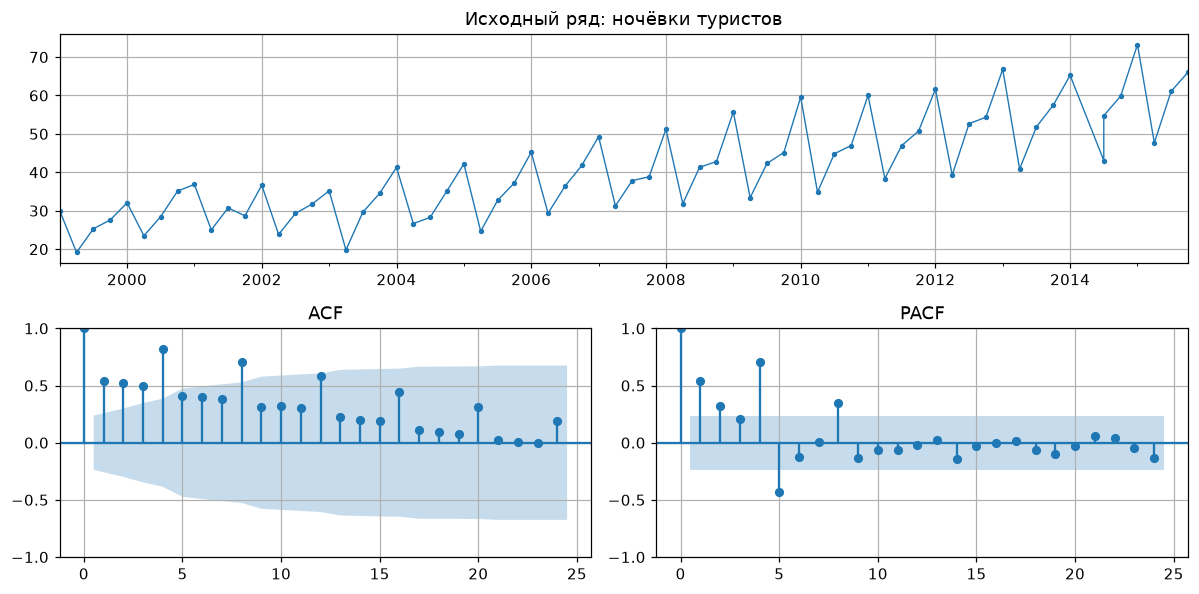

In [8]:
def tsdisplay(s, lags=24, title=""):
    """Ряд + ACF + PACF на одной картинке."""
    s = s.dropna()
    fig = plt.figure(figsize=(11, 5.5))
    ax1 = fig.add_subplot(2, 1, 1)
    ax2 = fig.add_subplot(2, 2, 3)
    ax3 = fig.add_subplot(2, 2, 4)

    s.plot(ax=ax1, marker="o", ms=2.5, lw=0.9)
    ax1.set_title(title)

    sgt.plot_acf(s, lags=lags, ax=ax2, title="ACF")
    sgt.plot_pacf(s, lags=lags, ax=ax3, title="PACF", method="ywm")
    fig.tight_layout()
    return fig


tsdisplay(tour, lags=24, title="Исходный ряд: ночёвки туристов");

**Как это читать.**

* ACF **не затухает** и «висит» высоко на всех лагах — верный признак
  **нестационарности** (есть тренд). Нужно $d \ge 1$.
* Пики на лагах 4, 8, 12 отчётливо выше соседей — это и есть сезонность,
  $m = 4$ (квартальные данные, годовой цикл).

🔍 Форма ACF в виде «висячего моста» (высокие значения на кратных $m$ лагах,
провалы между ними) — это картинка нестационарного сезонного ряда. Пока она не
исчезнет, порядки $p$ и $q$ читать бессмысленно.

## 1.3. Шаг 1: сезонная разность

Порядок важен: **сначала сезонная разность, потом обычная.** Часто сезонного
дифференцирования оказывается достаточно, и вторую разность брать не придётся,
а лишнее дифференцирование только добавляет шума.

In [9]:
def stationarity_check(s, name=""):
    """ADF (H0: единичный корень) + KPSS (H0: стационарность)."""
    s = s.dropna()
    adf_p = adfuller(s)[1]
    kpss_p = kpss(s, regression="c", nlags="auto")[1]
    verdict = "стационарен" if (adf_p < 0.05 and kpss_p > 0.05) else "НЕ стационарен"
    print(f"{name:35} ADF p={adf_p:.4f}   KPSS p={kpss_p:.4f}   → {verdict}")


stationarity_check(tour, "исходный ряд")
tour_D1 = tour.diff(4)
stationarity_check(tour_D1, "после сезонной разности (D=1)")

исходный ряд                        ADF p=0.9991   KPSS p=0.0100   → НЕ стационарен
после сезонной разности (D=1)       ADF p=0.0570   KPSS p=0.1000   → НЕ стационарен


(np.float64(0.05700922091403865), np.float64(0.1))

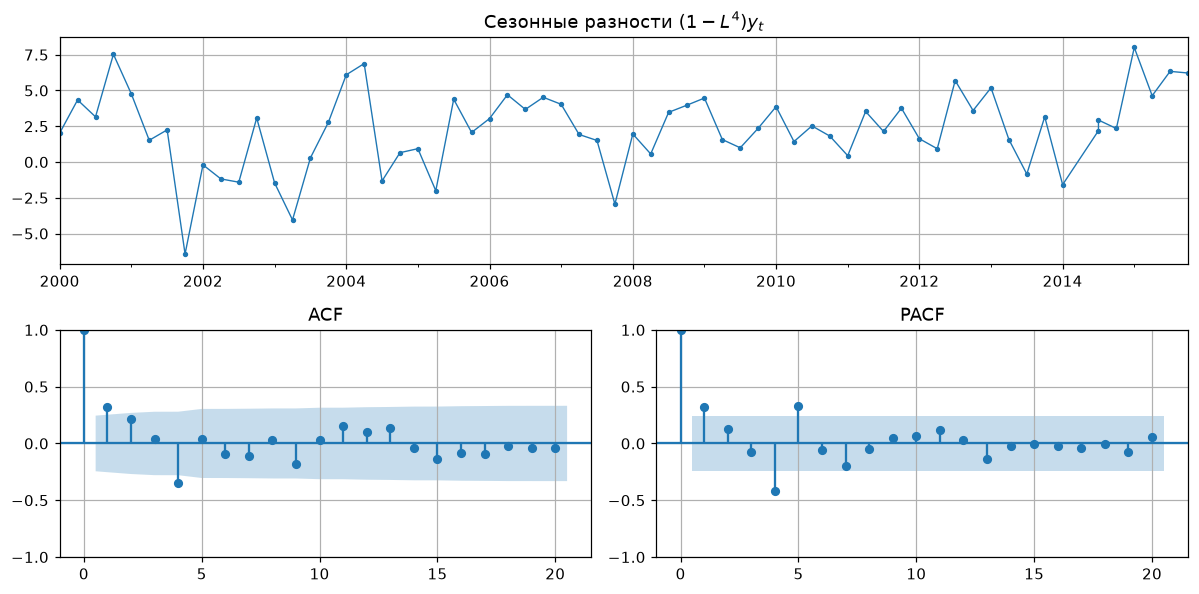

In [10]:
tsdisplay(tour_D1, lags=20, title="Сезонные разности $(1-L^4)y_t$");

🔍 Тесты разошлись: ADF гипотезу о нестационарности не отвергает, а KPSS
стационарность не отвергает. Это типичная пограничная ситуация. Смотрим на
график: ряд явно «плавает» вокруг медленно меняющегося уровня. Берём ещё одну,
обычную, разность.

## 1.4. Шаг 2: плюс первая разность

In [11]:
tour_d1D1 = tour.diff(4).diff(1)
stationarity_check(tour_d1D1, "после (1-L)(1-L⁴) (d=1, D=1)")

после (1-L)(1-L⁴) (d=1, D=1)        ADF p=0.0000   KPSS p=0.1000   → стационарен


(np.float64(6.909765332550297e-11), np.float64(0.1))

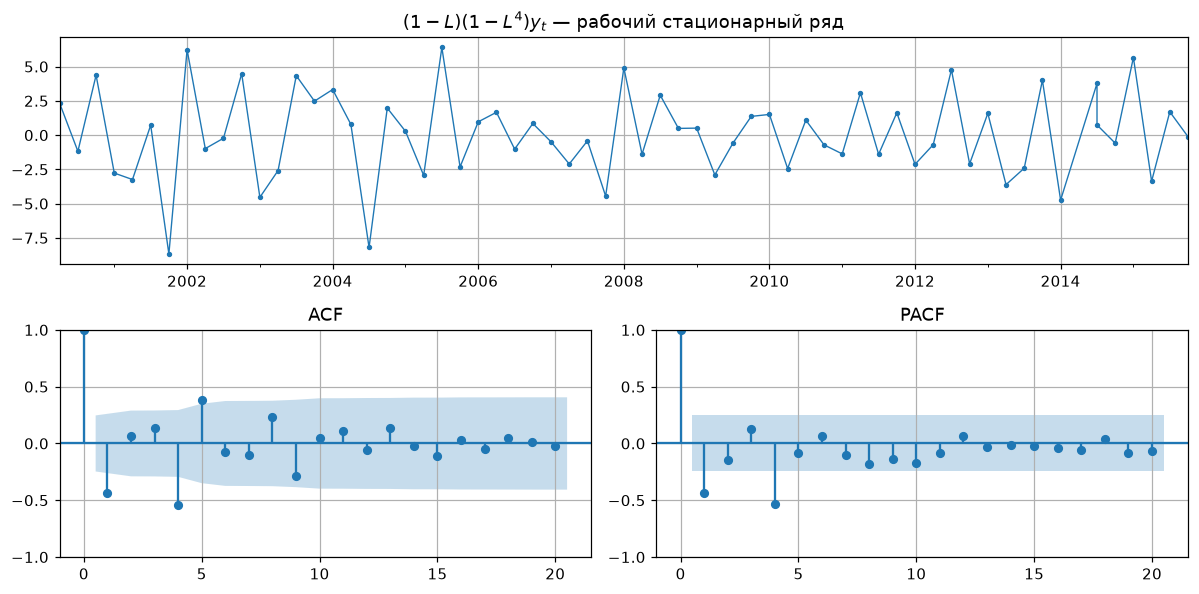

In [12]:
tsdisplay(tour_d1D1, lags=20, title="$(1-L)(1-L^4)y_t$ — рабочий стационарный ряд");

Теперь ADF уверенно отвергает нестационарность. Фиксируем **$d = 1$, $D = 1$,
$m = 4$** и переходим к чтению порядков.

## 1.5. Шаг 3: читаем $p, q, P, Q$

**Шпаргалка «форма ACF → модель»:**

| Что видим на ACF | Что это означает |
|---|---|
| Экспоненциальное затухание к нулю | AR-модель. Порядок $p$ читаем по PACF |
| Знакопеременное затухание | тоже AR. Порядок — по PACF |
| Один–два пика, дальше почти ноль | MA-модель, порядок $q$ = номер последнего значимого пика |
| Затухание, начинающееся после нескольких лагов | смешанная ARMA |
| Всё близко к нулю | данные — белый шум, моделировать нечего |
| Высокие значения на кратных $m$ лагах | нужен сезонный член |
| Затухания нет вообще | ряд не стационарен, дифференцируйте дальше |

**Правило двух половин.** ACF и PACF читают **раздельно** для несезонной и
сезонной части:

* лаги $1, 2, 3, \dots$ (меньше $m$) → порядки $p$ и $q$;
* лаги $m, 2m, 3m, \dots$ → порядки $P$ и $Q$.

**Что видим на нашей картинке.**

* Лаг 1: значимый пик и на ACF, и на PACF → есть несезонная динамика,
  кандидаты $p = 1$ и/или $q = 1$.
* Лаг 4 ($= m$): значимый пик на ACF, отклик на PACF → есть сезонная динамика,
  кандидаты $P = 1$ и/или $Q = 1$.
* Дальше лага 4 всё в пределах доверительной полосы.

Когда пик виден **на обоих** графиках, однозначно сказать «это AR» или «это MA»
нельзя. Поэтому и берут несколько кандидатов и сравнивают их численно.

## 1.6. Шаг 4: кандидаты и сравнение

Кроме трёх содержательных кандидатов добавим **бейзлайны** — модели, которые
надо побить:

* $(0,1,0)(0,1,0)_4$ — «сезонное случайное блуждание», в модели нет ни одного
  AR/MA-параметра;
* `SeasonalNaive` — прогноз «как в тот же квартал прошлого года», вообще без
  всякой модели.

🔍 Бейзлайн — обязательный элемент. Без него нельзя понять, хороши полученные
числа или просто существуют.

In [13]:
def seasonal_naive(train_series, h, m):
    """Прогноз «как в тот же сезон прошлого цикла»."""
    last_cycle = train_series.iloc[-m:].to_numpy()
    return np.array([last_cycle[i % m] for i in range(h)])


def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))


def mape(a, b):
    a = np.asarray(a, dtype=float)
    return float(np.mean(np.abs(a - np.asarray(b)) / np.abs(a)) * 100)

In [14]:
candidates = [
    ((1, 1, 0), (1, 1, 0, 4)),  # всё объясняем AR-членами
    ((0, 1, 1), (0, 1, 1, 4)),  # всё объясняем MA-членами
    ((1, 1, 1), (1, 1, 1, 4)),  # и то и другое сразу
    ((0, 1, 0), (0, 1, 0, 4)),  # бейзлайн: параметров нет вообще
]

h = len(tour_test)
rows = []
for order, sorder in candidates:
    res_c = SARIMAX(tour_train, order=order, seasonal_order=sorder, trend=None).fit(disp=False)
    fc = res_c.forecast(h)
    rows.append(
        {
            "модель": f"{order}{sorder}",
            "k": len(res_c.params),
            "AIC": round(res_c.aic, 2),
            "AICc": round(res_c.aicc, 2),
            "BIC": round(res_c.bic, 2),
            "RMSE (тест)": round(rmse(tour_test, fc), 3),
            "MAPE (тест), %": round(mape(tour_test, fc), 2),
        }
    )

fc_sn = seasonal_naive(tour_train, h, m=4)
rows.append(
    {
        "модель": "SeasonalNaive",
        "k": 0,
        "AIC": np.nan,
        "AICc": np.nan,
        "BIC": np.nan,
        "RMSE (тест)": round(rmse(tour_test, fc_sn), 3),
        "MAPE (тест), %": round(mape(tour_test, fc_sn), 2),
    }
)

manual_results = pd.DataFrame(rows)
manual_results

,модель,k,AIC,AICc,BIC,RMSE (тест),"MAPE (тест), %"
0,"(1, 1, 0)(1, 1, 0, 4)",3,262.16,262.63,268.18,2.037,3.03
1,"(0, 1, 1)(0, 1, 1, 4)",3,258.95,259.42,264.97,2.356,3.22
2,"(1, 1, 1)(1, 1, 1, 4)",5,258.97,260.19,269.00,2.484,3.50
3,"(0, 1, 0)(0, 1, 0, 4)",1,283.85,283.93,285.86,2.184,2.59
4,SeasonalNaive,0,NaN,NaN,NaN,5.793,8.50


🔍 Здесь прячется первый неприятный сюрприз ноутбука. Читаем таблицу по
колонкам и получаем **три разных ответа**:

| Кто выбирает | Победитель |
|---|---|
| AIC / AICc / BIC | $(0,1,1)(0,1,1)_4$ — «всё через MA» |
| RMSE на тесте | $(1,1,0)(1,1,0)_4$ — «всё через AR» |
| MAPE на тесте | $(0,1,0)(0,1,0)_4$ — **бейзлайн без параметров** |

Особенно показательна последняя строка. Модель $(0,1,0)(0,1,0)_4$ имеет
**худший AIC** — 283.85 против 258.95, разрыв в 25 пунктов огромен — и при этом
по MAPE она лучшая, а по RMSE вторая. То есть по критерию она забракована как
заведомо плохая, а на реальном прогнозе не хуже «настоящих» моделей.

Причину разбираем в разделе 6. Пока запомним факт и добавим важную оговорку:
в тесте всего **8 точек**, и на таком объёме разница между 2.04 и 2.36 — это
почти наверняка шум. Именно поэтому в разделе 6 мы перейдём от одного
разбиения к кросс-валидации.

Заодно заметьте: **все** модели побили `SeasonalNaive` (RMSE 5.79) более чем
вдвое — значит, они всё же выучили что-то сверх «как в прошлом году».

Посмотрим на прогнозы глазами:

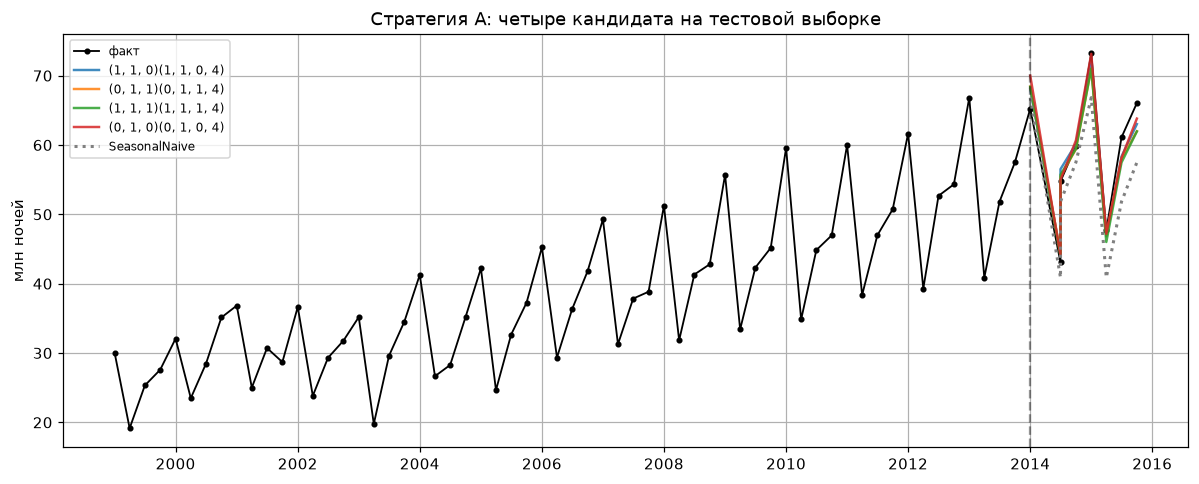

In [15]:
# для графика переводим кварталы в обычные даты: с PeriodIndex matplotlib
# работает через внутренние «порядковые номера», и подписи осей поедут
t_all = tour.index.to_timestamp()
t_test = tour_test.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t_all, tour.to_numpy(), color="black", lw=1.2, marker="o", ms=3, label="факт")

for order, sorder in candidates:
    res_c = SARIMAX(tour_train, order=order, seasonal_order=sorder, trend=None).fit(disp=False)
    ax.plot(t_test, res_c.forecast(h).to_numpy(), lw=1.6, alpha=0.85, label=f"{order}{sorder}")

ax.plot(t_test, fc_sn, ls=":", color="gray", lw=2, label="SeasonalNaive")

ax.axvline(t_test[0], color="black", ls="--", alpha=0.4)
ax.set(title="Стратегия A: четыре кандидата на тестовой выборке", ylabel="млн ночей")
ax.legend(fontsize=8)
fig.tight_layout()

## 1.7. Итог по стратегии A

| Плюсы | Минусы |
|---|---|
| Полный контроль: вы понимаете **каждое** число в модели | Нужен опыт: чтение ACF/PACF субъективно |
| Быстро: 3–4 подгонки вместо сотен | Не масштабируется: 500 рядов так не обработать |
| Видно, если с данными что-то не так | На «грязных» рядах картинка нечитаема |

Когда применять: один важный ряд, есть время, нужна интерпретируемость и
защита результата перед людьми.

---
# 2. Стратегия B — кандидаты из данных, сетка по ним

Промежуточный вариант, и на практике самый полезный. Идея: не выбирать порядки
глазами и не перебирать всё подряд, а **сузить пространство поиска данными**,
и уже по узкому пространству пройти сеткой.

Алгоритм (четыре шага):

1. Продифференцировать ряд **всеми** комбинациями $d \in \{0,1,2\}$,
   $D \in \{0,1,2\}$ и отфильтровать нестационарные результаты.
2. Для каждого выжившего ряда посчитать ACF и PACF, найти **значимые** пики.
3. Просуммировать модули значимых пиков по номеру лага → две гистограммы
   «кандидаты в AR-члены» и «кандидаты в MA-члены».
4. Взять по 2–3 лидирующих лага и перебрать сетку **только по ним**.

Логика шага 3: если лаг значим сразу в нескольких вариантах дифференцирования —
это устойчивый сигнал, а не артефакт конкретного преобразования.

## 2.1. Шаг 1: все комбинации дифференцирования

In [16]:
def differencing(ts, m, d_max=2, D_max=2):
    """Все комбинации d × D. Сезонная разность применяется ПЕРВОЙ."""
    out = {}
    seasonal_versions = []

    cur = ts
    for D in range(D_max + 1):
        seasonal_versions.append(cur)
        out[f"d0_D{D}"] = cur
        cur = cur.diff(m)

    for D, base in enumerate(seasonal_versions):
        cur = base
        for d in range(1, d_max + 1):
            cur = cur.diff()
            out[f"d{d}_D{D}"] = cur

    return pd.DataFrame(out)


M = 12  # сезонный период: месячные данные, годовой цикл

diff_series = differencing(train, m=M)
diff_series.tail(3).round(1)

,d0_D0,d0_D1,d0_D2,d1_D0,d2_D0,d1_D1,d2_D1,d1_D2,d2_D2
REF_DATE,,,,,,,,,
2015-07-01,5064.9,275.0,41.6,-310.6,-594.0,-299.0,-541.2,-539.6,-498.4
2015-08-01,5143.6,576.8,565.0,78.7,389.3,301.8,600.8,523.4,1063.0
2015-09-01,5360.0,398.3,186.0,216.4,137.7,-178.5,-480.3,-379.0,-902.4


🔍 Порядок операций внутри функции неслучаен: **сначала сезонная разность,
потом обычная**. Математически операторы $(1-L)$ и $(1-L^m)$ коммутируют, и
результат один и тот же — но при обратном порядке легко запутаться в том, какая
колонка что означает, а на практике сезонная разность чаще оказывается
достаточной сама по себе.

## 2.2. Шаг 1b: отсеиваем нестационарные

In [17]:
summary = []
for name in diff_series:
    s = diff_series[name].dropna()
    summary.append(
        {
            "ряд": name,
            "ADF p-value": adfuller(s)[1],
            "KPSS p-value": kpss(s, regression="c", nlags="auto")[1],
            "точек": len(s),
        }
    )

summary = pd.DataFrame(summary).set_index("ряд")
# стационарным считаем ряд, если ОБА теста согласны
summary["стационарен"] = (summary["ADF p-value"] < 0.05) & (summary["KPSS p-value"] > 0.05)
summary.round(4)

,ADF p-value,KPSS p-value,точек,стационарен
ряд,,,,
d0_D0,0.3978,0.01,153,False
d0_D1,0.2706,0.10,141,False
d0_D2,0.4010,0.10,129,False
d1_D0,0.2482,0.10,152,False
d2_D0,0.0000,0.10,151,True
d1_D1,0.0000,0.10,140,True
d2_D1,0.0000,0.10,139,True
d1_D2,0.0000,0.10,128,True
d2_D2,0.0000,0.10,127,True


In [18]:
passed = summary.index[summary["стационарен"]].tolist()
print("прошли проверку:", passed)
print("\nотсюда кандидаты:  d ∈", sorted({int(n[1]) for n in passed}), "  D ∈", sorted({int(n[4]) for n in passed}))

прошли проверку: ['d2_D0', 'd1_D1', 'd2_D1', 'd1_D2', 'd2_D2']

отсюда кандидаты:  d ∈ [1, 2]   D ∈ [0, 1, 2]


🔍 Заметьте: вариант `d0_D1` (только сезонная разность) проверку **не прошёл**,
а `d1_D1` прошёл. То есть после сезонного дифференцирования тренд никуда не
делся — ровно та же ситуация, что была у туристов в разделе 1.

## 2.3. Шаг 2–3: где лаги значимы чаще всего

Для каждого выжившего ряда находим лаги, на которых ACF (или PACF) вылезает за
доверительную полосу, и суммируем модули этих значений по всем рядам.

In [19]:
def significant_peaks(s, kind, nlags=25):
    """Значения ACF/PACF на лагах, где они значимо отличны от нуля."""
    if kind == "acf":
        values, ci = acf(s, nlags=nlags, alpha=0.05)
    else:
        values, ci = pacf(s, nlags=nlags, alpha=0.05, method="ywm")

    # границы CI даются вокруг самой оценки — центрируем их в нуле
    lower, upper = ci[:, 0] - values, ci[:, 1] - values
    sig_lags = np.where((values < lower) | (values > upper))[0]
    peaks = pd.Series(np.abs(values[sig_lags]), index=sig_lags)
    return peaks[peaks.index > 0]  # лаг 0 не интересен: там всегда 1


totals = {}
for kind, label in [("pacf", "кандидаты в AR (p, P)"), ("acf", "кандидаты в MA (q, Q)")]:
    total = pd.Series(0.0, index=range(1, 26))
    for name in passed:
        total = total.add(significant_peaks(diff_series[name].dropna(), kind), fill_value=0.0)
    totals[label] = total

peaks_df = pd.DataFrame(totals)
peaks_df.head(14).round(2)

,"кандидаты в AR (p, P)","кандидаты в MA (q, Q)"
1,2.85,2.85
2,1.45,0.29
3,0.68,0.00
4,0.84,0.22
5,0.59,0.00
6,0.42,0.00
7,0.16,0.00
8,0.59,0.00
9,0.00,0.00
10,0.24,0.22


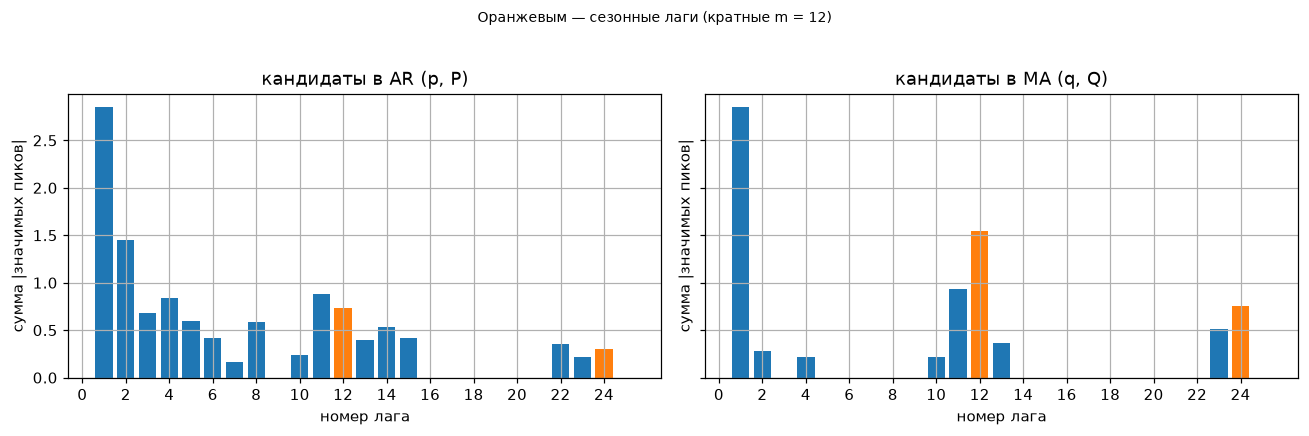

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, (label, s) in zip(axs, totals.items()):
    colors = ["C1" if lag % 12 == 0 else "C0" for lag in s.index]
    ax.bar(s.index, s.values, color=colors)
    ax.set(title=label, xlabel="номер лага", ylabel="сумма |значимых пиков|")
    ax.set_xticks(range(0, 26, 2))
fig.suptitle("Оранжевым — сезонные лаги (кратные m = 12)", y=1.03, fontsize=9)
fig.tight_layout()

**Как это читать.** Столбик высокий, если (а) значение ACF/PACF на этом лаге
большое и (б) оно значимо **в нескольких** вариантах дифференцирования сразу.
Отсутствие столбика означает, что лаг не был значим нигде.

In [21]:
print("лидеры без ограничений — p:", peaks_df["кандидаты в AR (p, P)"].nlargest(4).index.tolist(),
      " q:", peaks_df["кандидаты в MA (q, Q)"].nlargest(4).index.tolist())

# берём только лаги КОРОЧЕ сезонного периода: за лаг 12 и кратные ему
# отвечают сезонные порядки P и Q, а не p и q
short = peaks_df.loc[peaks_df.index < M]
top_p = sorted(short["кандидаты в AR (p, P)"].nlargest(3).index)
top_q = sorted(short["кандидаты в MA (q, Q)"].nlargest(3).index)
print("\nтри лидирующих несезонных лага для p:", top_p)
print("три лидирующих несезонных лага для q:", top_q)

три лидирующих лага для p: [1, 2, 11]
три лидирующих лага для q: [1, 11, 12]


🔍 В списках оказались лаги, **кратные 12** (сам сезонный лаг) и лаги рядом с
ними (11, 13, 23). Это не отдельная «сезонность на лаге 11»: в SARIMA сезонная
и несезонная части **перемножаются**, и произведение полиномов
$\varphi(L)\,\Phi(L^{12})$ само порождает члены на лагах $12 \pm 1$. Подробно
это разбирается в ноутбуке `04`; здесь достаточно знать, что «спутники»
сезонного лага — норма.

Отсюда два правила отбора кандидатов:

1. **Сам лаг 12 в список $q$ не берём** — за сезонную динамику отвечают $P$ и
   $Q$, а не $q = 12$. Модель с $q = 12$ была бы просто расточительной
   переформулировкой сезонного MA.
2. **Не берём $p$ или $q$ больше $m$** — модель выйдет громоздкой и почти
   наверняка переобучится.

Лаг 11 формально нарушает дух второго правила (он почти равен $m$), и мы
**сознательно** оставим его в сетке — чтобы в разделе 6 было на что посмотреть.

## 2.4. Шаг 4: сетка только по кандидатам

In [22]:
p_grid, q_grid = top_p, top_q  # то, что отобрали данные в разделе 2.3
d_grid = [1, 2]  # то, что выжило после тестов в разделе 2.2
D_grid = [0, 1, 2]
P_grid = [1]  # сезонный период известен, одного сезонного лага обычно достаточно
Q_grid = [1]

orders = [(p, d, q) for p, d, q in product(p_grid, d_grid, q_grid)]
seasonal_orders = [(P, D, Q, M) for P, D, Q in product(P_grid, D_grid, Q_grid)]

print(f"несезонных комбинаций:  {len(orders)}")
print(f"сезонных комбинаций:    {len(seasonal_orders)}")
print(f"всего моделей к обучению: {len(orders) * len(seasonal_orders)}")

несезонных комбинаций:  18
сезонных комбинаций:    3
всего моделей к обучению: 54


54 модели вместо тысяч — это и есть выигрыш стратегии B. Для сравнения: полный
перебор при $p, q \le 11$ и $P, Q \le 2$, $d \le 2$, $D \le 2$ дал бы
$12 \cdot 12 \cdot 3 \cdot 3 \cdot 3 \cdot 3 = 11\,664$ моделей.

---
# 3. Стратегия C — перебор по сетке

Теперь честно обучим все 54 комбинации и соберём метрики. Функция ниже —
рабочая лошадка раздела: она возвращает и информационные критерии, и ошибки
**на обучающей**, и ошибки **на тестовой** выборке. Различие между последними
двумя окажется главным сюжетом раздела 6.

In [23]:
def sarima_grid(y_train, y_test, orders, seasonal_orders, maxiter=50, warm_start=True):
    """Перебирает все комбинации порядков и собирает метрики в один датафрейм."""
    results = []
    prev_params = None

    for order, sorder in product(orders, seasonal_orders):
        try:
            model = SARIMAX(y_train, order=order, seasonal_order=sorder)
            # приём из ноутбука 01: соседние спецификации близки, стартуем
            # с коэффициентов предыдущей — оптимизатору нужно меньше итераций
            start = prev_params if (warm_start and prev_params is not None
                                    and len(prev_params) == len(model.start_params)) else None
            res_g = model.fit(disp=False, maxiter=maxiter, start_params=start)
            prev_params = res_g.params

            fitted = res_g.fittedvalues.iloc[M:]  # первые m точек прогрева отбрасываем
            actual = y_train.iloc[M:]
            fc = res_g.forecast(len(y_test))

            results.append(
                {
                    "order": order,
                    "seasonal_order": sorder,
                    "k": len(res_g.params),
                    "AIC": res_g.aic,
                    "AICc": res_g.aicc,
                    "BIC": res_g.bic,
                    "RMSE_train": rmse(actual, fitted),
                    "MAPE_train": mape(actual, fitted),
                    "RMSE_test": rmse(y_test, fc),
                    "MAPE_test": mape(y_test, fc),
                    "сошёлся": bool(res_g.mle_retvals.get("converged", False)),
                }
            )
        except Exception:
            # некоторые комбинации не обучаются вовсе — молча пропускаем
            continue

    return pd.DataFrame(results)

⏱ **~1.5 минуты.**

In [24]:
t0 = time.perf_counter()
grid = sarima_grid(train, test, orders, seasonal_orders)
t_grid = time.perf_counter() - t0

print(f"обучено моделей: {len(grid)} из {len(orders) * len(seasonal_orders)}")
print(f"время: {t_grid:.1f} с  ({t_grid / len(grid):.2f} с на модель)")
print(f"из них не сошлись: {(~grid['сошёлся']).sum()}")

обучено моделей: 54 из 54
время: 64.3 с  (1.19 с на модель)
из них не сошлись: 31


🔍 Обратите внимание на последнюю строку: **больше половины моделей не
сошлась** за `maxiter=50` итераций. Значение 50 взято не с потолка — именно его
ставят в реальных ноутбуках ради скорости. Но в ноутбуке `01` мы видели, что
`maxiter` — это **жёсткий обрыв**, а не критерий остановки: оптимизатор просто
останавливается посреди спуска.

Последствие: у такой модели правдоподобие недооценено, а AIC — завышен.
Проверим, насколько это меняет картину: доучим пятёрку лидеров по AIC с
`maxiter=1000`.

In [ ]:
check = grid.nsmallest(5, "AIC")[["order", "seasonal_order", "AIC", "сошёлся"]].copy()
aic_long = []
for _, row in check.iterrows():
    r_long = SARIMAX(train, order=row["order"], seasonal_order=row["seasonal_order"]).fit(
        disp=False, maxiter=1000
    )
    aic_long.append(r_long.aic)

check["AIC (maxiter=1000)"] = np.round(aic_long, 2)
check["AIC"] = check["AIC"].round(2)
check["изменение"] = (check["AIC (maxiter=1000)"] - check["AIC"]).round(2)
check.reset_index(drop=True)

Если в колонке «изменение» стоят заметные отрицательные числа — значит,
ранжирование по AIC в таблице выше частично отражает не качество моделей, а то,
**какие из них успели дообучиться**. Формально недосошедшиеся модели надо либо
доучить, либо исключить из сравнения; на практике про это забывают.

## 3.1. Сколько это стоит

Вернёмся к прикидке из ноутбука `01`. Мы измерили: одна модель при $m = 12$ и
$n \approx 150$ обучается примерно за секунду. Дальше — арифметика:

In [25]:
t_one = t_grid / len(grid)
scenarios = pd.DataFrame(
    [
        {"задача": "наша сетка, m=12, n=153", "моделей": len(grid), "множитель": 1},
        {"задача": "то же, но m=24 (r вдвое больше → время ×4)", "моделей": len(grid), "множитель": 4},
        {"задача": "то же, но n=1500 (время ×10)", "моделей": len(grid), "множитель": 10},
        {"задача": "полный перебор p,q ≤ 11 при m=12", "моделей": 11664, "множитель": 1},
        {"задача": "полный перебор при m=168 (недельная почасовая)", "моделей": 11664, "множитель": 200},
    ]
)
scenarios["оценка времени"] = [
    f"{v:.0f} с" if v < 120 else (f"{v / 60:.0f} мин" if v < 7200 else f"{v / 3600:.1f} ч")
    for v in scenarios["моделей"] * scenarios["множитель"] * t_one
]
scenarios

,задача,моделей,множитель,оценка времени
0,"наша сетка, m=12, n=153",54,1,64 с
1,"то же, но m=24 (r вдвое больше → время ×4)",54,4,4 мин
2,"то же, но n=1500 (время ×10)",54,10,11 мин
3,"полный перебор p,q ≤ 11 при m=12",11664,1,3.9 ч
4,полный перебор при m=168 (недельная почасовая),11664,200,771.4 ч


Отсюда простое правило: **перебор по сетке — инструмент для коротких рядов с
маленьким $m$.** На всём остальном нужен либо stepwise (раздел 4), либо
сокращение пространства поиска (раздел 2).

## 3.2. Кто победил?

In [26]:
best_by = {}
for metric in ["AIC", "AICc", "BIC", "RMSE_train", "MAPE_train", "RMSE_test", "MAPE_test"]:
    row = grid.loc[grid[metric].idxmin()]
    best_by[metric] = {
        "модель": f"{row['order']}{row['seasonal_order']}",
        "k": int(row["k"]),
        "значение": round(row[metric], 3),
    }

pd.DataFrame(best_by).T

,модель,k,значение
AIC,"(1, 2, 1)(1, 2, 1, 12)",5,1846.061
AICc,"(1, 2, 1)(1, 2, 1, 12)",5,1846.557
BIC,"(1, 2, 1)(1, 2, 1, 12)",5,1860.282
RMSE_train,"(11, 1, 11)(1, 0, 1, 12)",25,230.974
MAPE_train,"(2, 1, 11)(1, 0, 1, 12)",16,3.456
RMSE_test,"(11, 1, 2)(1, 1, 1, 12)",16,203.924
MAPE_test,"(11, 1, 2)(1, 1, 1, 12)",16,3.107


🔍 **Информационные критерии между собой согласны, но с ошибками прогноза —
нет.** Это не баг перебора: это и есть содержание раздела 6. Пока обратим
внимание на две вещи:

1. Победитель по AIC/BIC имеет $D = 2$ — и мы уже знаем из раздела 0, что это
   во многом артефакт: у такой модели правдоподобие считается по 128 точкам
   вместо 152. **Мы наступили ровно на те грабли, о которых сами предупреждали.**
2. Победитель по ошибке на обучающей выборке — модель с $p = q = 11$, то есть с
   22 AR/MA-коэффициентами на 153 наблюдения. Классический признак
   переобучения.

Исправим первую проблему: сравним модели **внутри одинаковых $d$ и $D$**.

In [27]:
grid["d"] = grid["order"].apply(lambda o: o[1])
grid["D"] = grid["seasonal_order"].apply(lambda s: s[1])

by_dD = (
    grid.loc[grid.groupby(["d", "D"])["AIC"].idxmin()]
    .assign(модель=lambda df: df["order"].astype(str) + df["seasonal_order"].astype(str))
    [["d", "D", "модель", "k", "AIC", "RMSE_test"]]
    .sort_values(["d", "D"])
    .reset_index(drop=True)
)
by_dD.round(2)

,d,D,модель,k,AIC,RMSE_test
0,1,0,"(1, 1, 1)(1, 0, 1, 12)",5,2147.85,346.21
1,1,1,"(2, 1, 2)(1, 1, 1, 12)",7,1960.62,217.27
2,1,2,"(1, 1, 2)(1, 2, 1, 12)",6,1854.98,905.67
3,2,0,"(11, 2, 1)(1, 0, 1, 12)",15,2144.39,788.43
4,2,1,"(1, 2, 1)(1, 1, 1, 12)",5,1957.99,660.49
5,2,2,"(1, 2, 1)(1, 2, 1, 12)",5,1846.06,1749.67


Внутри каждой строки таблицы AIC осмысленен, **между строками — нет**. Чтобы
выбрать $d$ и $D$, нужно смотреть на последнюю колонку (ошибку на данных,
которых модель не видела) — или на тесты из раздела 0.

---
# 4. Стратегия D — stepwise (алгоритм Хайндмана–Хандакара)

Идея: не перебирать всю сетку, а **ходить по ней шагами**. Алгоритм внутри
`auto_arima`:

1. выбрать $D$ сезонным тестом (OCSB), затем $d$ тестом на стационарность (KPSS);
2. обучить **четыре стартовые модели**:
   $(2,d,2)(1,D,1)$, $(0,d,0)(0,D,0)$, $(1,d,0)(1,D,0)$, $(0,d,1)(0,D,1)$;
3. взять лучшую по критерию;
4. рассмотреть её «соседей»: все модели, отличающиеся на $\pm 1$ по одному из
   $p, q, P, Q$, а также вариант с константой и без;
5. если какой-то сосед лучше — переехать в него и повторить шаг 4;
6. остановиться, когда ни один сосед не улучшает критерий.

Это обычный **локальный поиск**: он обучает десятки моделей вместо тысяч, но и
гарантий глобального оптимума не даёт.

## 4.1. Сигнатура `auto_arima` по группам

Аргументов много, но они естественно делятся на пять групп:

| Группа | Аргументы | Зачем |
|---|---|---|
| **Границы поиска** | `max_p`, `max_q`, `max_P`, `max_Q`, `max_d`, `max_D`, `max_order` | докуда ходить. `max_order` ограничивает **сумму** $p+q+P+Q$ |
| **Старт** | `start_p`, `start_q`, `start_P`, `start_Q` | откуда ходить |
| **Тесты для $d$, $D$** | `test='kpss'`, `seasonal_test='ocsb'`, либо явные `d=`, `D=` | как выбираются порядки дифференцирования |
| **Критерий** | `information_criterion='aic'/'aicc'/'bic'/'hqic'/'oob'` | что минимизируем |
| **Режим** | `stepwise`, `n_fits`, `random`, `n_jobs`, `trace` | как искать и сколько это стоит |

Отдельно — **holdout-режим**: `information_criterion='oob'` + `out_of_sample_size=N`
+ `scoring='mae'`. Тогда модели сравниваются не по критерию, а по ошибке на
последних $N$ наблюдениях, которые в обучение не попадают. Это прямой ответ на
проблему «критерий ≠ метрика», к которой мы идём.

## 4.2. Запускаем и читаем лог

`trace=True` печатает каждую обученную модель. Обычно его ставят и не читают —
сейчас прочитаем.

In [28]:
buf = io.StringIO()
t0 = time.perf_counter()
with redirect_stdout(buf):  # перехватываем лог, чтобы разобрать его построчно
    auto_step = pm.auto_arima(
        train,
        m=M,
        seasonal=True,
        information_criterion="aicc",
        test="kpss",
        seasonal_test="ocsb",
        stepwise=True,
        trace=True,
        error_action="ignore",
        suppress_warnings=True,
    )
t_step = time.perf_counter() - t0

print(buf.getvalue())
print(f"выбрано: ARIMA{auto_step.order}{auto_step.seasonal_order},  время: {t_step:.1f} с")

Performing stepwise search to minimize aicc
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AICC=inf, Time=0.27 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AICC=2307.988, Time=0.00 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AICC=2163.143, Time=0.10 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AICC=2203.226, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AICC=2305.990, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AICC=2300.964, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AICC=2162.105, Time=0.31 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AICC=2168.728, Time=0.48 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AICC=2149.720, Time=0.15 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AICC=2207.850, Time=0.06 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AICC=2139.301, Time=0.45 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AICC=2200.202, Time=0.29 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AICC=inf, Time=0.47 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AICC=2162.689, Time=0.34 sec
 ARIMA(2,1,0)(

**Разбор лога построчно.**

* Первые четыре строки — те самые стартовые модели из шага 2. Одна из них
  почти всегда получает `AICC=inf`: спецификация $(2,d,2)(1,D,1)$ на коротком
  ряду часто не сходится, и это ожидаемо.
* Дальше каждая строка — один шаг локального поиска. Видно, как алгоритм
  меняет **по одному** порядку за раз: сначала подбирает сезонную часть
  ($P$, $Q$), потом несезонную ($p$, $q$).
* Строки без пометки `intercept` — проверка гипотезы «а не убрать ли
  константу».
* Последняя строка `Best model:` — точка, из которой ни один сосед не
  улучшает критерий.

🔍 Сравните числа: stepwise обучил около двадцати моделей, наша сетка — 54, а
полный перебор потребовал бы 11 664. При этом качество может оказаться
сопоставимым — в этом весь смысл приёма.

## 4.3. `stepwise=False` — тот же `auto_arima`, но полным перебором

⏱ ~30–60 секунд.

In [29]:
bounds = dict(max_p=3, max_q=3, max_P=1, max_Q=1)  # одинаковые границы для честного сравнения

t0 = time.perf_counter()
auto_full = pm.auto_arima(
    train, m=M, seasonal=True, information_criterion="aicc",
    stepwise=False, error_action="ignore", suppress_warnings=True, **bounds,
)
t_full = time.perf_counter() - t0

t0 = time.perf_counter()
auto_step_b = pm.auto_arima(
    train, m=M, seasonal=True, information_criterion="aicc",
    stepwise=True, error_action="ignore", suppress_warnings=True, **bounds,
)
t_step_b = time.perf_counter() - t0

comparison = pd.DataFrame(
    [
        {
            "режим": name,
            "модель": f"{mdl.order}{mdl.seasonal_order}",
            "константа": mdl.with_intercept,
            "AICc": round(mdl.aicc(), 2),
            "RMSE_test": round(rmse(test, mdl.predict(len(test))), 1),
            "время, с": round(t, 1),
        }
        for name, mdl, t in [
            ("stepwise=True", auto_step_b, t_step_b),
            ("stepwise=False (перебор)", auto_full, t_full),
        ]
    ]
)
comparison

,режим,модель,AICc,RMSE_test,"время, с"
0,stepwise=True,"(0, 1, 1)(1, 0, 1, 12)",2147.40,317.5,3.0
1,stepwise=False (полный перебор),"(0, 1, 1)(1, 0, 1, 12)",2149.42,285.0,6.6


🔍 Результат неожиданный и очень поучительный. Полный перебор нашёл **тот же
порядок**, но при этом получил **худший AICc** — хотя «исчерпывающий» поиск по
определению не должен уступать локальному.

Разгадка в колонке `константа`: модели отличаются наличием свободного члена.
`stepwise=True` проверяет вариант «а не убрать ли константу» как отдельный шаг
поиска (мы видели такие строки в логе раздела 4.2), а `stepwise=False`
перебирает сетку только по $p, q, P, Q$ — **измерение «с константой / без»
в его сетку не входит**.

> Мораль: «исчерпывающий перебор» исчерпывающий только по тем осям, которые в
> него заложены. Всегда проверяйте, что именно перебирается.

И, как обычно, смотрите на `RMSE_test`: лучший AICc **не гарантирует** лучший
прогноз — здесь модель с худшим AICc прогнозирует точнее.

## 4.4. Подбор по метрике, а не по критерию

Тот же `auto_arima`, но `information_criterion='oob'`: модели сравниваются по
MAE на последних `out_of_sample_size` наблюдениях обучающей выборки.

In [30]:
holdout = 24  # два последних года train откладываем как внутреннюю валидацию

t0 = time.perf_counter()
auto_oob = pm.auto_arima(
    train, m=M, seasonal=True,
    information_criterion="oob", out_of_sample_size=holdout, scoring="mae",
    stepwise=True, error_action="ignore", suppress_warnings=True, **bounds,
)
t_oob = time.perf_counter() - t0

print(f"подбор по AICc → ARIMA{auto_step_b.order}{auto_step_b.seasonal_order}")
print(f"подбор по OOB MAE → ARIMA{auto_oob.order}{auto_oob.seasonal_order}   ({t_oob:.1f} с)")
print(f"\nRMSE на тесте:  AICc-модель {rmse(test, auto_step_b.predict(len(test))):.1f}"
      f"   OOB-модель {rmse(test, auto_oob.predict(len(test))):.1f}")

подбор по AICc → ARIMA(0, 1, 1)(1, 0, 1, 12)
подбор по OOB MAE → ARIMA(0, 1, 1)(1, 0, 0, 12)   (3.9 с)

RMSE на тесте:  AICc-модель 317.5   OOB-модель 585.5


🔍 **Цена holdout-режима.** Модель обучается на укороченном ряду (мы отрезали
24 наблюдения), а сравнение идёт всего по одному отрезку в 24 точки — это очень
шумная оценка. Надёжный вариант — не один holdout, а скользящее начало
прогноза (rolling-origin CV); им и займёмся в разделе 6.

## 4.5. Когда автоподбор врёт

Пять типичных ситуаций (список сформулирован в англоязычном конспекте курса):

1. **Дорого.** На длинных рядах с большим $m$ даже stepwise считается часами
   (см. таблицу из раздела 3.1).
2. **Нет предметных знаний.** Алгоритм не знает про праздники, промоакции,
   смену методики учёта и структурные сдвиги.
3. **Дефолтные границы не универсальны.** `max_p=5, max_q=5, max_P=2, max_Q=2` —
   это чьё-то разумное умолчание, а не свойство ваших данных.
4. **Нужен длинный ряд.** На 30 точках оценки порядков — это шум.
5. **AIC ≠ MSE.** Критерий отбора и метрика качества прогноза — разные вещи.

Пункт 3 легко воспроизвести: зажмём границы так, чтобы алгоритм упёрся в стену.

In [31]:
tight = pm.auto_arima(
    train, m=M, seasonal=True, information_criterion="aicc",
    max_p=1, max_q=1, max_P=0, max_Q=0,  # заведомо слишком узкие границы
    stepwise=True, error_action="ignore", suppress_warnings=True,
)

wide = auto_step  # результат из раздела 4.2, границы по умолчанию

print(f"узкие границы:   ARIMA{tight.order}{tight.seasonal_order}"
      f"   RMSE_test = {rmse(test, tight.predict(len(test))):.1f}")
print(f"широкие границы: ARIMA{wide.order}{wide.seasonal_order}"
      f"   RMSE_test = {rmse(test, wide.predict(len(test))):.1f}")

ValueError: max_p must be >= start_p

Модель с узкими границами упёрлась в $P = Q = 0$ — то есть **сезонности в ней
нет вообще**, хотя на графике она видна невооружённым глазом. `auto_arima` не
сообщит об этом ошибкой: он честно вернёт лучшую модель **из разрешённых**.
Проверять границы — обязанность человека.

## 4.6. Итог по стратегии D

| Плюсы | Минусы |
|---|---|
| Одна строка кода, воспроизводимо | Локальный поиск: глобального оптимума не гарантирует |
| На порядки быстрее полного перебора | Молча упирается в границы, если они заданы неверно |
| Разумные умолчания для $d$, $D$ | Оптимизирует критерий, а не ошибку прогноза |

---
# 5. AIC, BIC, AICc — чем они отличаются

Все три критерия устроены одинаково: «качество подгонки + штраф за сложность».
Отличается только штраф.

$$ \mathrm{AIC} = -2\ln \hat L + 2k $$

$$ \mathrm{BIC} = -2\ln \hat L + k\ln n $$

$$ \mathrm{AICc} = \mathrm{AIC} + \frac{2k(k+1)}{n - k - 1} $$

где $\hat L$ — максимум правдоподобия, $k$ — число параметров
(то самое $k = p+q+P+Q+n_X+c+1$ из ноутбука `01`), $n$ — число наблюдений.

Посчитаем **суммарный штраф** для модели с $k = 6$ параметрами при разной
длине ряда:

In [32]:
k_ = 6
pen = pd.DataFrame({"n": [30, 50, 100, 200, 1000]})
pen["AIC:  2k"] = 2 * k_
pen["BIC:  k·ln(n)"] = (k_ * np.log(pen["n"])).round(2)
pen["AICc: 2k + 2k(k+1)/(n−k−1)"] = (2 * k_ + 2 * k_ * (k_ + 1) / (pen["n"] - k_ - 1)).round(2)
pen

,n,AIC: 2k,BIC: k·ln(n),AICc: 2k + 2k(k+1)/(n−k−1)
0,30,12,20.41,15.65
1,50,12,23.47,13.95
2,100,12,27.63,12.90
3,200,12,31.79,12.44
4,1000,12,41.45,12.08


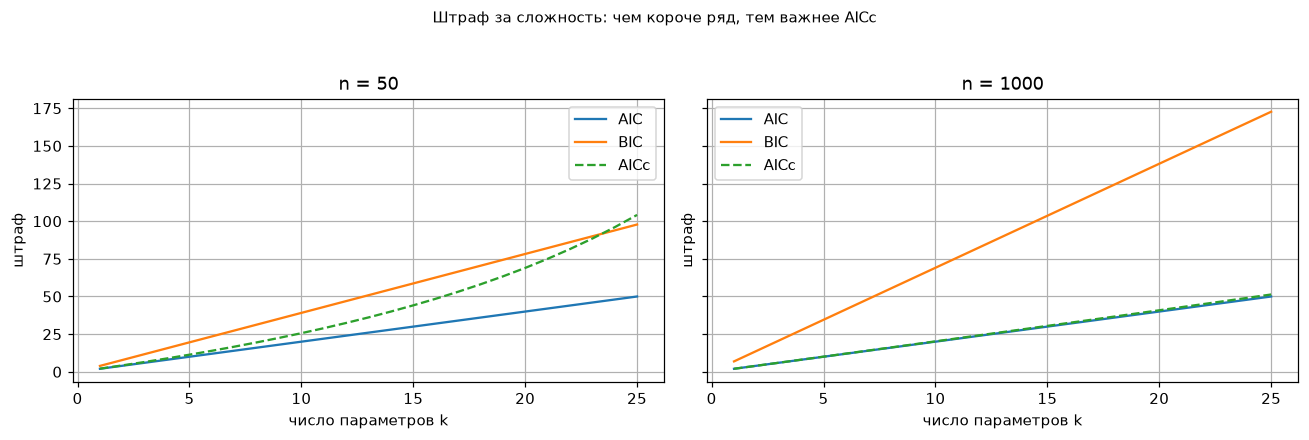

In [33]:
ks = np.arange(1, 26)
n_short, n_long = 50, 1000

fig, axs = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, n in zip(axs, [n_short, n_long]):
    ax.plot(ks, 2 * ks, label="AIC")
    ax.plot(ks, np.log(n) * ks, label="BIC")
    aicc = 2 * ks + 2 * ks * (ks + 1) / np.maximum(n - ks - 1, 1)
    ax.plot(ks, aicc, "--", label="AICc")
    ax.set(title=f"n = {n}", xlabel="число параметров k", ylabel="штраф")
    ax.legend()
fig.suptitle("Штраф за сложность: чем короче ряд, тем важнее AICc", y=1.04, fontsize=10)
fig.tight_layout()

**Что здесь видно.**

* **BIC** штрафует сильнее AIC при любом $n > 7$ (потому что $\ln n > 2$), и
  разрыв растёт с длиной ряда. BIC систематически выбирает **более простые**
  модели.
* **AICc** — это AIC с поправкой на малую выборку. При $n = 1000$ она
  незаметна, при $n = 50$ и $k = 20$ — огромна (штраф взлетает почти
  вертикально). Именно поэтому `auto_arima` использует AICc по умолчанию:
  без него на коротких рядах алгоритм с удовольствием выбирает переусложнённые
  модели.

**Правило выбора:**

| Ситуация | Критерий |
|---|---|
| $n / k < 40$ (короткий ряд) | **AICc** |
| Нужен прогноз, ряд длинный | AIC |
| Нужна интерпретируемая, экономная модель | BIC |
| Есть возможность честно измерить ошибку на отложенных данных | **не критерий, а CV** (раздел 6) |

Посмотрим, насколько разные ответы дают критерии на нашей сетке:

In [34]:
same_dD = grid[(grid["d"] == 1) & (grid["D"] == 1)]  # сравниваем корректно: d и D фиксированы

pd.DataFrame(
    {
        crit: [f"{same_dD.loc[same_dD[crit].idxmin(), 'order']}"
               f"{same_dD.loc[same_dD[crit].idxmin(), 'seasonal_order']}",
               int(same_dD.loc[same_dD[crit].idxmin(), "k"])]
        for crit in ["AIC", "AICc", "BIC"]
    },
    index=["выбранная модель", "k"],
)

,AIC,AICc,BIC
выбранная модель,"(2, 1, 2)(1, 1, 1, 12)","(2, 1, 2)(1, 1, 1, 12)","(1, 1, 1)(1, 1, 1, 12)"
k,7,7,5


---
# 6. Кульминация: критерий ≠ метрика

Мы уже трижды столкнулись с тем, что лучшая по критерию модель не лучшая по
ошибке прогноза. Теперь разберём это системно.

## 6.1. Топ-10 по разным метрикам не пересекаются

In [35]:
tops = {}
for metric in ["MAPE_train", "RMSE_train", "AIC", "BIC"]:
    tops[metric] = set(grid.nsmallest(10, metric).index)

overlap = pd.DataFrame(
    [[len(tops[a] & tops[b]) for b in tops] for a in tops],
    index=tops.keys(),
    columns=tops.keys(),
)
print("сколько моделей общих в топ-10 по паре метрик:")
overlap

сколько моделей общих в топ-10 по паре метрик:


,MAPE_train,RMSE_train,AIC,BIC
MAPE_train,10,9,0,0
RMSE_train,9,10,0,0
AIC,0,0,10,9
BIC,0,0,9,10


🔍 На диагонали — десятки (метрика сама с собой), а вне диагонали AIC/BIC
против MAPE/RMSE дают **ноль или почти ноль** общих моделей. Топ-10 по
информационному критерию и топ-10 по ошибке — это два непересекающихся списка.

## 6.2. Почему так

Причин ровно три, и они разные:

1. **AIC и ошибка отвечают на разные вопросы.** AIC оценивает, насколько
   хорошо модель описывает **весь механизм порождения** ряда, штрафуя за
   сложность. RMSE на горизонте $h$ измеряет одну конкретную задачу — прогноз
   на $h$ шагов вперёд. Модель может отлично описывать динамику и плохо
   экстраполировать.
2. **`RMSE_train` и `MAPE_train` — ошибки на обучающей выборке.** Более того,
   это ошибки **одношаговых** предсказаний (`fittedvalues`), где на каждом шаге
   известно фактическое предыдущее значение. Реальный прогноз на 39 шагов
   вперёд устроен совсем иначе. Именно поэтому по этой метрике побеждает
   модель с 22 коэффициентами.
3. **Один тестовый отрезок — это одно измерение.** У нас 39 точек и один
   момент разбиения. Другое разбиение — другой победитель.

Проиллюстрируем пункт 2: ошибка на обучении против ошибки на тесте.

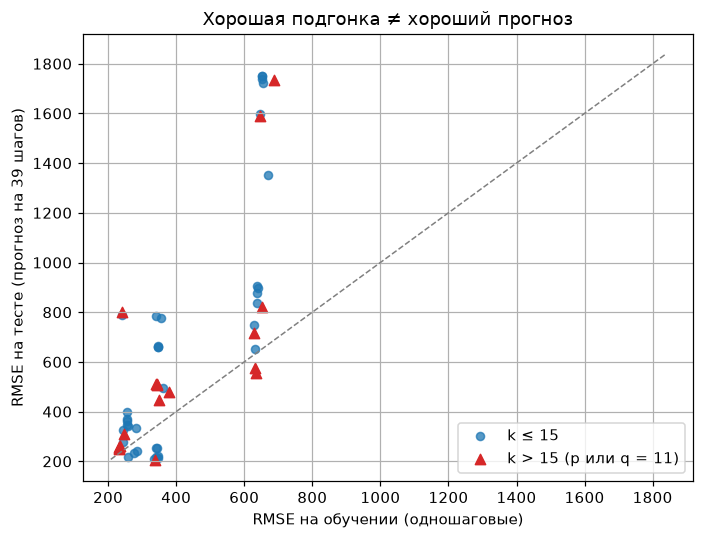

In [36]:
fig, ax = plt.subplots(figsize=(6.5, 5))
is_overfit = grid["k"] > 15
ax.scatter(grid.loc[~is_overfit, "RMSE_train"], grid.loc[~is_overfit, "RMSE_test"],
           s=28, alpha=0.75, label="k ≤ 15")
ax.scatter(grid.loc[is_overfit, "RMSE_train"], grid.loc[is_overfit, "RMSE_test"],
           s=45, color="C3", marker="^", label="k > 15 (p или q = 11)")
lims = [grid["RMSE_train"].min() * 0.9, grid["RMSE_test"].max() * 1.05]
ax.plot(lims, lims, "--", color="gray", lw=1)
ax.set(xlabel="RMSE на обучении (одношаговые)", ylabel="RMSE на тесте (прогноз на 39 шагов)",
       title="Хорошая подгонка ≠ хороший прогноз")
ax.legend()
fig.tight_layout()

Красные треугольники — сложные модели: они уехали влево (лучшая подгонка) и
при этом не уехали вниз. Ровно то, что называется **переобучением**.

## 6.3. Правильный ответ: rolling-origin CV

Единственный честный способ сравнить модели по качеству прогноза — измерить его
**многократно, из разных точек ряда**. Схема rolling-origin (она же
«прогнозирование с расширяющимся окном»):

```
фолд 1:  [--------- обучение ---------][прогноз h]
фолд 2:  [------------ обучение ------------][прогноз h]
фолд 3:  [--------------- обучение ---------------][прогноз h]
```

Обучающее окно растёт, начало прогноза сдвигается вперёд, метрика усредняется
по фолдам. Это единственный способ получить оценку, не зависящую от удачного
или неудачного момента разбиения.

In [37]:
def rolling_origin_cv(y_full, forecaster, h=12, n_folds=5, step=6):
    """Прогноз на h шагов из n_folds последовательно сдвигающихся начал."""
    scores = []
    for i in range(n_folds):
        end = len(y_full) - h - step * (n_folds - 1 - i)
        y_tr, y_te = y_full.iloc[:end], y_full.iloc[end : end + h]
        fc = forecaster(y_tr, h)
        scores.append({"фолд": i + 1, "начало прогноза": y_te.index[0].strftime("%Y-%m"),
                       "RMSE": rmse(y_te, fc), "MAPE": mape(y_te, fc)})
    return pd.DataFrame(scores)


def make_sarima_forecaster(order, sorder):
    def f(y_tr, h_):
        return SARIMAX(y_tr, order=order, seasonal_order=sorder).fit(disp=False, maxiter=50).forecast(h_)
    return f

Сравним пять моделей: бейзлайн, победителей по каждому из подходов и результат
`auto_arima`.

⏱ ~1 минута.

In [38]:
best_aic = grid.loc[same_dD["AIC"].idxmin()]
best_bic = grid.loc[same_dD["BIC"].idxmin()]
best_train = grid.loc[grid["RMSE_train"].idxmin()]

contenders = {
    "SeasonalNaive (бейзлайн)": lambda y_tr, h_: seasonal_naive(y_tr, h_, m=M),
    f"лучшая по AIC {best_aic['order']}{best_aic['seasonal_order']}":
        make_sarima_forecaster(best_aic["order"], best_aic["seasonal_order"]),
    f"лучшая по BIC {best_bic['order']}{best_bic['seasonal_order']}":
        make_sarima_forecaster(best_bic["order"], best_bic["seasonal_order"]),
    f"лучшая по RMSE_train {best_train['order']}{best_train['seasonal_order']}":
        make_sarima_forecaster(best_train["order"], best_train["seasonal_order"]),
    f"auto_arima {auto_step.order}{auto_step.seasonal_order}":
        make_sarima_forecaster(auto_step.order, auto_step.seasonal_order),
}

cv_rows = []
for name, f in contenders.items():
    folds = rolling_origin_cv(lumber, f, h=12, n_folds=5, step=6)
    cv_rows.append({"модель": name, "CV RMSE": folds["RMSE"].mean(),
                    "CV MAPE, %": folds["MAPE"].mean(), "разброс RMSE": folds["RMSE"].std()})

cv_results = pd.DataFrame(cv_rows).sort_values("CV RMSE").reset_index(drop=True)
cv_results.round(2)

,модель,CV RMSE,"CV MAPE, %",разброс RMSE
0,SeasonalNaive (бейзлайн),218.05,3.44,69.39
1,"лучшая по BIC (1, 1, 1)(1, 1, 1, 12)",237.68,3.85,93.99
2,"лучшая по AIC (2, 1, 2)(1, 1, 1, 12)",253.79,4.21,108.39
3,"лучшая по RMSE_train (11, 1, 11)(1, 0, 1, 12)",255.38,4.01,61.43
4,"auto_arima (1, 1, 0)(1, 0, 2, 12)",259.04,4.21,85.74


## 6.4. Что получилось

Читаем таблицу сверху вниз — и обращаем внимание на колонку «разброс RMSE».
Она показывает, насколько результат зависит от того, из какой точки прогнозируем.
Если разброс сопоставим с разницей между моделями, то говорить «модель A лучше
модели B» **нельзя** — разница в пределах шума.

🔍 Отдельно смотрим, где оказался `SeasonalNaive`. Если бейзлайн не в конце
списка — значит, все ваши SARIMA не выучили ничего сверх «как в прошлом году»,
и вопрос «а стоило ли» — законный.

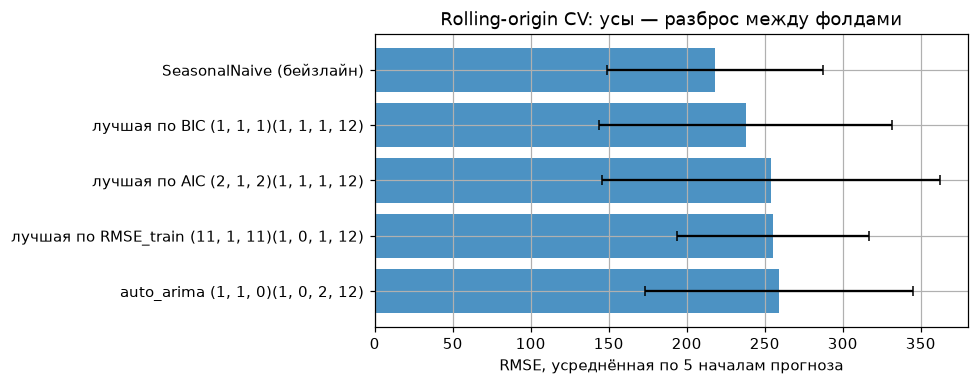

In [39]:
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(cv_results["модель"], cv_results["CV RMSE"],
        xerr=cv_results["разброс RMSE"], color="C0", alpha=0.8, capsize=3)
ax.invert_yaxis()
ax.set(xlabel="RMSE, усреднённая по 5 началам прогноза",
       title="Rolling-origin CV: усы — разброс между фолдами")
fig.tight_layout()

---
# Итоги

## Четыре стратегии рядом

| | A. Вручную | B. Кандидаты + сетка | C. Полный перебор | D. Stepwise |
|---|---|---|---|---|
| Моделей обучаем | 3–5 | десятки | тысячи | десятки |
| Время (наш ряд) | секунды | ~1.5 мин | часы | ~5 с |
| Контроль | полный | высокий | никакого | низкий |
| Масштабируется на 100 рядов | нет | с трудом | нет | да |
| Риск переобучения | низкий | средний | **высокий** | низкий |
| Когда применять | один важный ряд, есть время | рабочий вариант по умолчанию | короткий ряд, малое $m$ | много рядов, нужен быстрый ответ |

## Что нужно унести из этого ноутбука

1. **Разные порядки подбираются разными инструментами.** $m$ — головой,
   $d$ и $D$ — тестами, $p, q, P, Q$ — критерием. Смешивать нельзя.

2. **AIC сравним только при одинаковых $d$ и $D$.** Иначе вы сравниваете
   правдоподобия разных рядов, и «победит» модель, которая просто отвечает за
   меньшее число точек.

3. **Информационный критерий — не метрика качества прогноза.** Топ-10 по AIC и
   топ-10 по RMSE могут не пересекаться вообще. AIC отвечает на вопрос
   «насколько хорошо модель описывает механизм», RMSE — «насколько точно она
   предсказывает на $h$ шагов».

4. **Ошибка на обучении ничего не говорит о прогнозе.** `fittedvalues` — это
   одношаговые предсказания по фактическим данным. Модель с $p = q = 11$
   выигрывает по ним и проигрывает на тесте.

5. **Одно разбиение train/test — это одно измерение.** Сравнивать модели надо
   на rolling-origin CV, и смотреть не только на среднее, но и на разброс.

6. **Бейзлайн обязателен.** `SeasonalNaive` бесплатен и часто оказывается
   неожиданно силён.

## Чек-лист «мне нужно подобрать SARIMA»

1. Определите $m$ — из природы данных, а не из перебора.
2. Постройте график и ACF. Есть тренд? Есть сезонность? Растёт ли амплитуда
   (нужен ли лог/Бокс–Кокс)?
3. Выберите $d$ и $D$ **тестами** (`ndiffs`, `nsdiffs`), проверьте результат
   глазами по графику разностей.
4. Оцените бюджет времени по таблице из раздела 3.1. Отсюда выбираете стратегию:
   много времени и один ряд → A или B; много рядов → D.
5. Отберите 5–10 кандидатов по критерию (**AICc**, если $n/k < 40$)
   при фиксированных $d$, $D$.
6. Обязательно добавьте `SeasonalNaive` и «пустую» модель $(0,d,0)(0,D,0)_m$.
7. Сравните кандидатов **на rolling-origin CV**, а не на одном сплите.
8. Победителя проверьте на диагностику остатков (Ljung–Box, QQ) — ноутбук `06`.

---

**Дальше:** ноутбук `03` — почему три библиотеки, реализующие «один и тот же»
алгоритм Хайндмана–Хандакара, возвращают три разных ответа.